# Lesson 4a: Gaussian Mixture Models (GMM) — Theory

## Overview
Gaussian Mixture Models (GMM) extend K-Means by introducing probabilistic cluster membership. Instead of hard assignments, each point belongs to clusters with some probability. This lesson derives the Expectation-Maximization (EM) algorithm from first principles and explores the underlying mathematics.

**Learning Goals:**
- Understand Gaussian distributions and mixture models
- Derive the EM algorithm (E-step and M-step)
- Analyze convergence and log-likelihood
- Compare GMM to K-Means
- Implement EM from scratch using NumPy

## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from scipy.special import logsumexp
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')

## Part 1: Gaussian Distributions

### Univariate Gaussian
A univariate Gaussian (normal) distribution with mean $\mu$ and variance $\sigma^2$ has probability density:

$$p(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

### Multivariate Gaussian
For a $d$-dimensional Gaussian with mean $\boldsymbol{\mu} \in \mathbb{R}^d$ and covariance $\boldsymbol{\Sigma} \in \mathbb{R}^{d \times d}$:

$$p(\mathbf{x}) = \frac{1}{(2\pi)^{d/2}|\boldsymbol{\Sigma}|^{1/2}} \exp\left(-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^T\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})\right)$$

where $|\boldsymbol{\Sigma}|$ is the determinant of the covariance matrix.

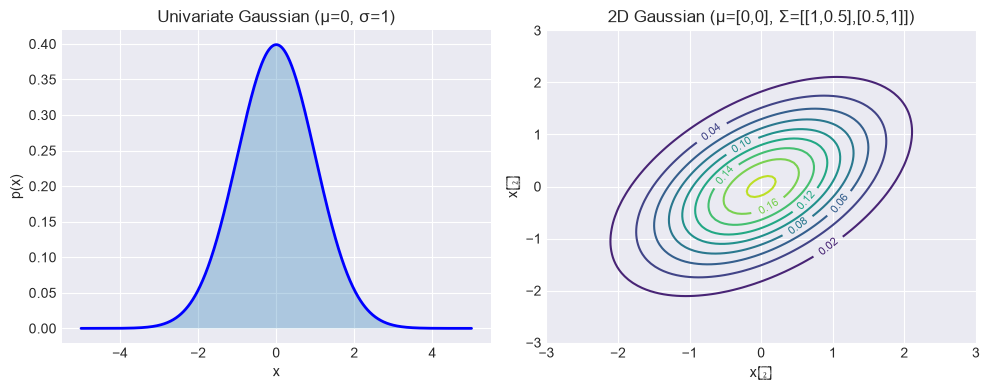

In [2]:
# Demonstrate univariate Gaussian
x = np.linspace(-5, 5, 1000)
mu, sigma = 0, 1
p_x = (1 / np.sqrt(2 * np.pi * sigma**2)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(x, p_x, 'b-', linewidth=2)
plt.fill_between(x, p_x, alpha=0.3)
plt.title('Univariate Gaussian (μ=0, σ=1)')
plt.xlabel('x')
plt.ylabel('p(x)')

# 2D Gaussian
from numpy.random import multivariate_normal as mv_normal
mu_2d = [0, 0]
sigma_2d = [[1, 0.5], [0.5, 1]]
x_2d = np.linspace(-3, 3, 100)
y_2d = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x_2d, y_2d)
pos = np.dstack((X, Y))
rv = multivariate_normal(mu_2d, sigma_2d)
Z = rv.pdf(pos)

plt.subplot(1, 2, 2)
contour = plt.contour(X, Y, Z, levels=10, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)
plt.title('2D Gaussian (μ=[0,0], Σ=[[1,0.5],[0.5,1]])')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.tight_layout()
plt.show()

## Part 2: Mixture Models

A **mixture model** is a weighted combination of $K$ component distributions:

$$p(\mathbf{x}) = \sum_{k=1}^{K} \pi_k p(\mathbf{x} | z=k)$$

where:
- $\pi_k$ is the **mixing coefficient** for component $k$ (satisfies $\sum_k \pi_k = 1$, $\pi_k \geq 0$)
- $p(\mathbf{x} | z=k)$ is the component distribution (typically Gaussian)
- $z \in \{1, 2, \ldots, K\}$ is the latent cluster assignment

### Gaussian Mixture Model (GMM)
In a GMM, each component is a Gaussian:

$$p(\mathbf{x}) = \sum_{k=1}^{K} \pi_k \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

**Parameters:** $(\pi_1, \ldots, \pi_K, \boldsymbol{\mu}_1, \ldots, \boldsymbol{\mu}_K, \boldsymbol{\Sigma}_1, \ldots, \boldsymbol{\Sigma}_K)$

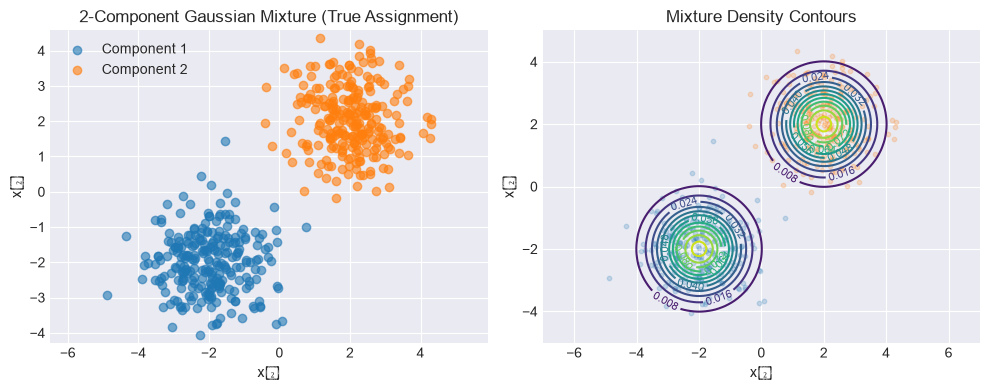

Data shape: (500, 2)
Component sizes: 250, 250


In [3]:
# Generate synthetic data from a 2-component GMM
n_samples = 500
K = 2

# Component 1: centered at (-2, -2)
component_1 = np.random.multivariate_normal([-2, -2], [[0.8, 0], [0, 0.8]], n_samples // 2)

# Component 2: centered at (2, 2)
component_2 = np.random.multivariate_normal([2, 2], [[0.8, 0], [0, 0.8]], n_samples // 2)

X_true = np.vstack([component_1, component_2])
y_true = np.hstack([np.zeros(n_samples // 2), np.ones(n_samples // 2)])

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
for k in range(K):
    plt.scatter(X_true[y_true == k, 0], X_true[y_true == k, 1], label=f'Component {k+1}', alpha=0.6)
plt.title('2-Component Gaussian Mixture (True Assignment)')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.legend()
plt.axis('equal')

# Visualize mixture density
x_range = np.linspace(-5, 5, 100)
y_range = np.linspace(-5, 5, 100)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
pos_grid = np.dstack((X_grid, Y_grid))

# Two components with equal weight
Z = 0.5 * multivariate_normal([-2, -2], [[0.8, 0], [0, 0.8]]).pdf(pos_grid) + \
    0.5 * multivariate_normal([2, 2], [[0.8, 0], [0, 0.8]]).pdf(pos_grid)

plt.subplot(1, 2, 2)
contour = plt.contour(X_grid, Y_grid, Z, levels=15, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)
plt.scatter(X_true[y_true == 0, 0], X_true[y_true == 0, 1], alpha=0.2, s=10)
plt.scatter(X_true[y_true == 1, 0], X_true[y_true == 1, 1], alpha=0.2, s=10)
plt.title('Mixture Density Contours')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.axis('equal')
plt.tight_layout()
plt.show()

print(f"Data shape: {X_true.shape}")
print(f"Component sizes: {np.sum(y_true == 0)}, {np.sum(y_true == 1)}")

## Part 3: Responsibilities (Soft Assignments)

The key difference between GMM and K-Means is **soft assignment**. For each point $\mathbf{x}_i$ and component $k$, we compute the **responsibility** $r_{ik}$:

$$r_{ik} = P(z_i = k | \mathbf{x}_i) = \frac{\pi_k p(\mathbf{x}_i | z=k)}{\sum_{j=1}^{K} \pi_j p(\mathbf{x}_i | z=j)}$$

This uses **Bayes' rule**:
- Numerator: prior × likelihood of component $k$
- Denominator: total likelihood (normalization)

**Interpretation:** $r_{ik}$ is the posterior probability that point $i$ belongs to cluster $k$.

In [4]:
# Example: compute responsibilities
def compute_responsibilities(X, pi, mu, sigma):
    """Compute soft assignments (responsibilities) for each point.
    
    Args:
        X: (n, d) data array
        pi: (K,) mixing coefficients
        mu: (K, d) cluster means
        sigma: (K, d, d) covariance matrices
    
    Returns:
        r: (n, K) responsibility matrix
    """
    n, K = X.shape[0], len(pi)
    likelihood = np.zeros((n, K))
    
    # Compute likelihood for each component
    for k in range(K):
        rv = multivariate_normal(mu[k], sigma[k])
        likelihood[:, k] = rv.pdf(X)
    
    # Weighted likelihood
    weighted = likelihood * pi[np.newaxis, :]
    
    # Normalize to get responsibilities
    r = weighted / (weighted.sum(axis=1, keepdims=True) + 1e-10)
    
    return r

# Initialize parameters
pi_init = np.array([0.5, 0.5])
mu_init = np.array([[-2, -2], [2, 2]])
sigma_init = np.array([[[0.8, 0], [0, 0.8]], [[0.8, 0], [0, 0.8]]])

r = compute_responsibilities(X_true, pi_init, mu_init, sigma_init)

print(f"Responsibilities shape: {r.shape}")
print(f"First 5 points responsibilities (cluster 0, cluster 1):")
print(r[:5])
print(f"Responsibilities sum to 1 (checking first point): {r[0].sum()}")

Responsibilities shape: (500, 2)
First 5 points responsibilities (cluster 0, cluster 1):
[[9.99999989e-01 1.02400069e-08]
 [9.99966103e-01 3.38935401e-05]
 [9.99999999e-01 2.53854961e-10]
 [9.99925558e-01 7.44377325e-05]
 [9.99999996e-01 2.85797928e-09]]
Responsibilities sum to 1 (checking first point): 0.9999999988517759


## Part 4: The EM Algorithm

The **Expectation-Maximization (EM) algorithm** finds maximum likelihood estimates for GMM parameters by iterating two steps:

### E-Step (Expectation)
Compute responsibilities using current parameters:
$$r_{ik} = \frac{\pi_k \mathcal{N}(\mathbf{x}_i | \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}{\sum_j \pi_j \mathcal{N}(\mathbf{x}_i | \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}$$

### M-Step (Maximization)
Update parameters to maximize expected log-likelihood:

$$N_k = \sum_{i=1}^{n} r_{ik} \quad \text{(effective size of cluster } k\text{)}$$

$$\pi_k^{\text{new}} = \frac{N_k}{n}$$

$$\boldsymbol{\mu}_k^{\text{new}} = \frac{1}{N_k} \sum_{i=1}^{n} r_{ik} \mathbf{x}_i$$

$$\boldsymbol{\Sigma}_k^{\text{new}} = \frac{1}{N_k} \sum_{i=1}^{n} r_{ik} (\mathbf{x}_i - \boldsymbol{\mu}_k^{\text{new}})(\mathbf{x}_i - \boldsymbol{\mu}_k^{\text{new}})^T$$

In [5]:
def gmm_em(X, K, n_iterations=20, tol=1e-3):
    """Fit GMM using EM algorithm.
    
    Args:
        X: (n, d) data array
        K: number of clusters
        n_iterations: max iterations
        tol: convergence tolerance
    
    Returns:
        pi, mu, sigma: GMM parameters
        responsibilities: (n, K) soft assignments
        log_likelihood_history: list of log-likelihoods
    """
    n, d = X.shape
    
    # Initialize parameters randomly
    indices = np.random.choice(n, K, replace=False)
    mu = X[indices].copy()
    sigma = np.array([np.eye(d) for _ in range(K)])
    pi = np.ones(K) / K
    
    log_likelihood_history = []
    
    for iteration in range(n_iterations):
        # E-Step: Compute responsibilities
        r = compute_responsibilities(X, pi, mu, sigma)
        
        # Compute log-likelihood
        likelihood = np.zeros((n, K))
        for k in range(K):
            rv = multivariate_normal(mu[k], sigma[k])
            likelihood[:, k] = pi[k] * rv.pdf(X)
        
        total_likelihood = likelihood.sum(axis=1)
        log_likelihood = np.log(total_likelihood + 1e-10).sum()
        log_likelihood_history.append(log_likelihood)
        
        if iteration > 0 and abs(log_likelihood - log_likelihood_history[-2]) < tol:
            print(f"Converged at iteration {iteration}")
            break
        
        # M-Step: Update parameters
        N_k = r.sum(axis=0)
        pi = N_k / n
        
        for k in range(K):
            # Update mean
            mu[k] = np.sum(r[:, k:k+1] * X, axis=0) / (N_k[k] + 1e-10)
            
            # Update covariance
            diff = X - mu[k]
            weighted_diff = r[:, k:k+1] * diff
            sigma[k] = np.dot(weighted_diff.T, diff) / (N_k[k] + 1e-10)
            
            # Regularize to prevent singular matrices
            sigma[k] += np.eye(d) * 1e-6
    
    return pi, mu, sigma, r, log_likelihood_history

# Fit GMM on our data
pi_final, mu_final, sigma_final, r_final, log_lh = gmm_em(X_true, K=2, n_iterations=20)

print(f"\nFinal parameters:")
print(f"Mixing coefficients π: {pi_final}")
print(f"\nMeans:")
print(mu_final)
print(f"\nLog-likelihood history: {log_lh[:5]} ... {log_lh[-3:]}")

Converged at iteration 11

Final parameters:
Mixing coefficients π: [0.50086337 0.49913662]

Means:
[[ 1.99945536  2.05000392]
 [-1.99991923 -1.99426492]]

Log-likelihood history: [np.float64(-4666.634380983237), np.float64(-1841.1826046677106), np.float64(-1785.9797656840797), np.float64(-1764.8339977835658), np.float64(-1741.17542547746)] ... [np.float64(-1630.1166367031515), np.float64(-1630.1133256422456), np.float64(-1630.1131020952967)]


## Part 5: Convergence Analysis

### Log-Likelihood Objective
EM maximizes the **log-likelihood**:

$$\mathcal{L}(\boldsymbol{\theta}) = \log p(X | \boldsymbol{\theta}) = \sum_{i=1}^{n} \log \left( \sum_{k=1}^{K} \pi_k \mathcal{N}(\mathbf{x}_i | \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k) \right)$$

### EM Guarantees
1. **Monotonic improvement:** Each iteration increases (or maintains) the log-likelihood
2. **Convergence:** The algorithm converges to a local maximum
3. **Not global:** GMM has multiple local maxima; initialization matters

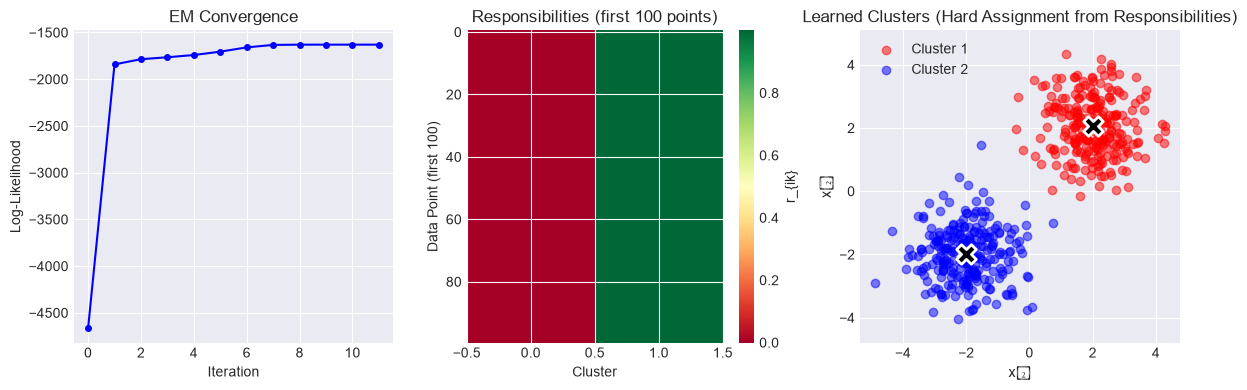

In [6]:
# Plot convergence
plt.figure(figsize=(12, 4))

# Log-likelihood convergence
plt.subplot(1, 3, 1)
plt.plot(log_lh, 'b-', marker='o', markersize=4)
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.title('EM Convergence')
plt.grid(True)

# Soft assignments (first 100 points)
plt.subplot(1, 3, 2)
plt.imshow(r_final[:100], aspect='auto', cmap='RdYlGn')
plt.xlabel('Cluster')
plt.ylabel('Data Point (first 100)')
plt.title('Responsibilities (first 100 points)')
plt.colorbar(label='r_{ik}')

# Clusters with learned means
plt.subplot(1, 3, 3)
assignment = np.argmax(r_final, axis=1)
colors = ['red', 'blue']
for k in range(K):
    plt.scatter(X_true[assignment == k, 0], X_true[assignment == k, 1], 
               c=colors[k], label=f'Cluster {k+1}', alpha=0.5)
    plt.scatter(mu_final[k, 0], mu_final[k, 1], c='black', marker='X', s=200, edgecolors='white', linewidth=2)
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('Learned Clusters (Hard Assignment from Responsibilities)')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

## Part 6: Covariance Types

The structure of the covariance matrix affects model complexity and interpretability:

### 1. Full Covariance ($O(d^2)$ parameters per cluster)
$$\boldsymbol{\Sigma}_k = \begin{bmatrix} \sigma_{k,11} & \sigma_{k,12} \\ \sigma_{k,21} & \sigma_{k,22} \end{bmatrix}$$
Most flexible; captures correlations between dimensions.

### 2. Tied Covariance ($O(d^2)$ total)
All clusters share the same covariance: $\boldsymbol{\Sigma}_k = \boldsymbol{\Sigma}$ for all $k$.
Reduces parameters; assumes equal variance structure.

### 3. Diagonal Covariance ($O(d)$ per cluster)
$$\boldsymbol{\Sigma}_k = \begin{bmatrix} \sigma_{k,1}^2 & 0 \\ 0 & \sigma_{k,2}^2 \end{bmatrix}$$
No correlations between dimensions.

### 4. Spherical Covariance ($O(1)$ per cluster)
$$\boldsymbol{\Sigma}_k = \sigma_k^2 I$$
Isotropic; all dimensions have equal variance.
Similar to K-Means when responsibilities are hard assignments.

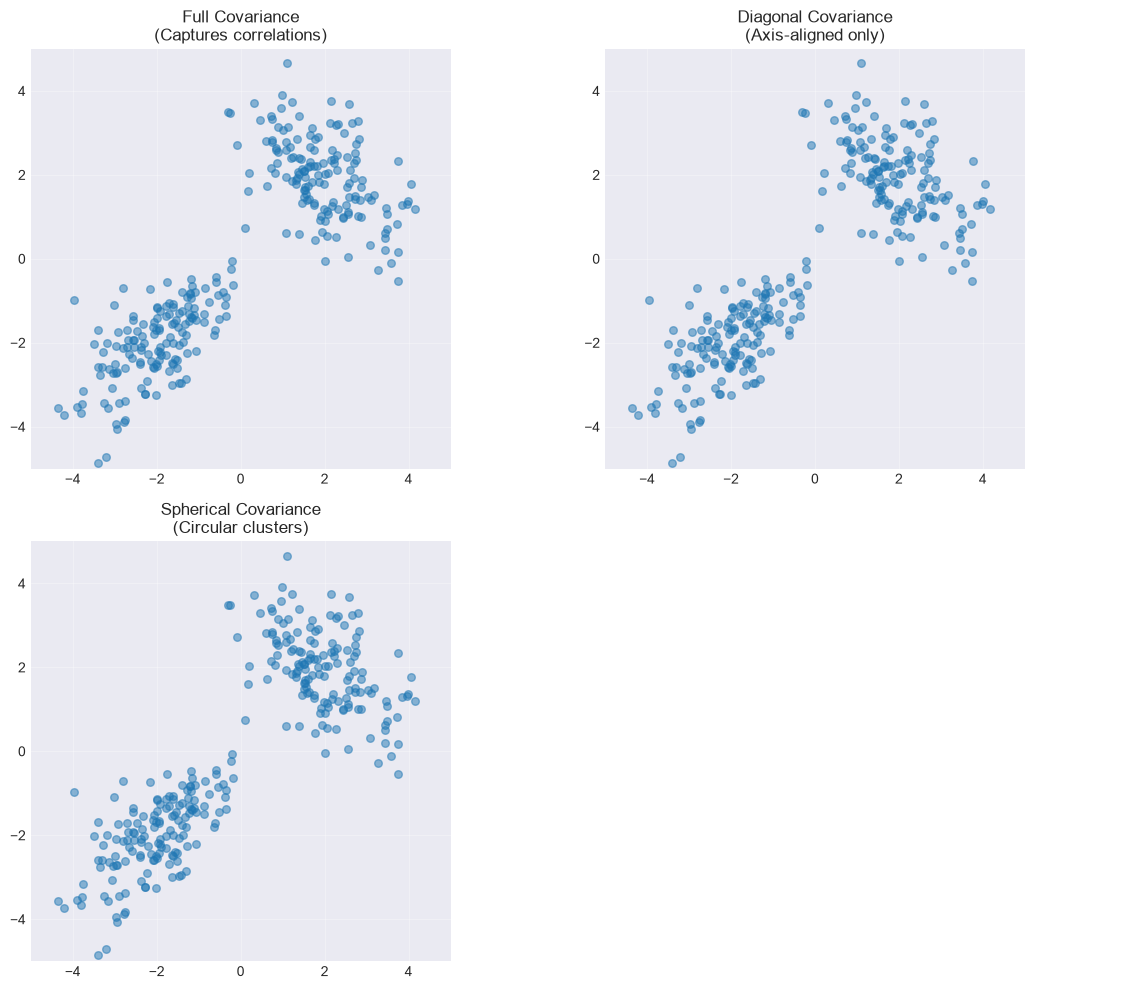

Covariance Types Trade-off:
- Full: Most flexible, but many parameters (risk of overfitting)
- Diagonal: Medium complexity, no cross-dimension correlations
- Spherical: Simplest, like K-Means (low variance, high bias)


In [7]:
# Demonstrate covariance types
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Data with different correlation structures
np.random.seed(42)
n = 300

# Cluster 1: positively correlated
cov1 = [[1, 0.7], [0.7, 1]]
c1 = np.random.multivariate_normal([-2, -2], cov1, n // 2)

# Cluster 2: negatively correlated  
cov2 = [[1, -0.5], [-0.5, 1]]
c2 = np.random.multivariate_normal([2, 2], cov2, n // 2)

X_corr = np.vstack([c1, c2])

# Covariance types to compare
cov_types = ['Full', 'Diagonal', 'Spherical']
positions = [(0, 0), (0, 1), (1, 0)]

for i, (cov_type, (ax_i, ax_j)) in enumerate(zip(cov_types, positions)):
    ax = axes[ax_i, ax_j]
    
    # For visualization, show what each covariance type assumes
    ax.scatter(X_corr[:, 0], X_corr[:, 1], alpha=0.5, s=30)
    
    if cov_type == 'Full':
        # Full covariance can capture the correlation structure
        ax.set_title('Full Covariance\n(Captures correlations)')
    elif cov_type == 'Diagonal':
        # Diagonal: axis-aligned ellipses
        ax.set_title('Diagonal Covariance\n(Axis-aligned only)')
    else:  # Spherical
        # Spherical: circular clusters
        ax.set_title('Spherical Covariance\n(Circular clusters)')
    
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

# Remove unused subplot
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("Covariance Types Trade-off:")
print("- Full: Most flexible, but many parameters (risk of overfitting)")
print("- Diagonal: Medium complexity, no cross-dimension correlations")
print("- Spherical: Simplest, like K-Means (low variance, high bias)")

## Part 7: GMM vs K-Means

| Feature | K-Means | GMM |
|---------|---------|-----|
| **Assignment** | Hard (discrete) | Soft (probabilistic) |
| **Objective** | Minimize within-cluster variance | Maximize likelihood |
| **Parameters** | Centers only | Means, covariances, mixing weights |
| **Model assumption** | Spherical clusters | Flexible Gaussian shapes |
| **Uncertainty** | None | Posterior probability |
| **Computational cost** | Faster (simple updates) | Slower (matrix operations) |
| **Initialization sensitivity** | Moderate | High |

### Key Insight
**K-Means is a limiting case of GMM**: When all covariances are $\sigma^2 I$ (spherical) and we use hard assignments, K-Means emerges as the EM algorithm with $\sigma \to 0$.

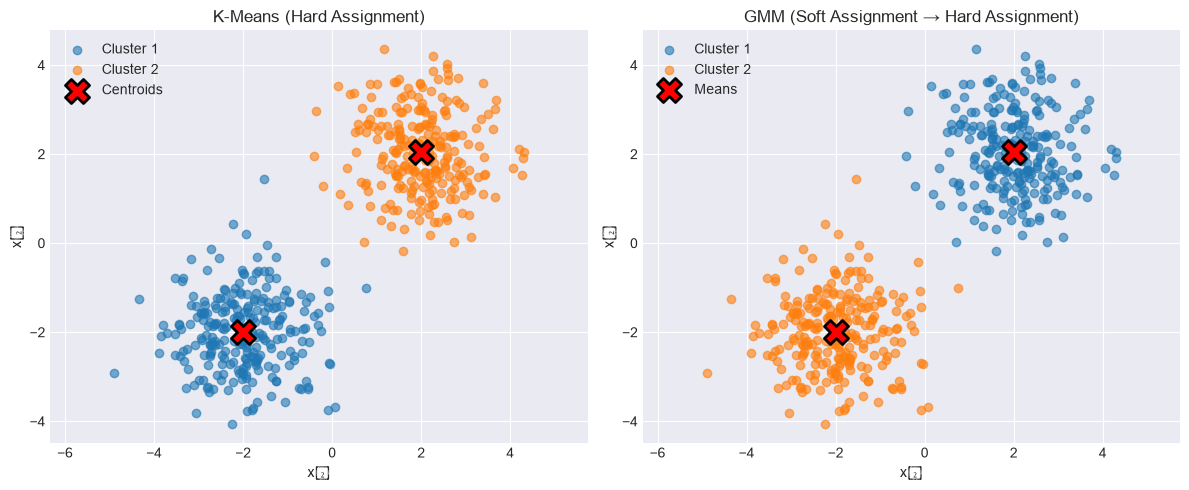

Agreement between K-Means and GMM hard assignments: 0.0%

K-Means inertia (sum of squared distances): 765.90
GMM log-likelihood: -1630.11


In [8]:
from sklearn.cluster import KMeans

# Compare GMM and K-Means on the same data
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_true)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# K-Means
ax = axes[0]
for k in range(2):
    ax.scatter(X_true[kmeans_labels == k, 0], X_true[kmeans_labels == k, 1],
              label=f'Cluster {k+1}', alpha=0.6)
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
          c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Centroids')
ax.set_title('K-Means (Hard Assignment)')
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.legend()
ax.axis('equal')

# GMM
ax = axes[1]
gmm_labels = np.argmax(r_final, axis=1)
for k in range(2):
    ax.scatter(X_true[gmm_labels == k, 0], X_true[gmm_labels == k, 1],
              label=f'Cluster {k+1}', alpha=0.6)
ax.scatter(mu_final[:, 0], mu_final[:, 1],
          c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Means')
ax.set_title('GMM (Soft Assignment → Hard Assignment)')
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.legend()
ax.axis('equal')

plt.tight_layout()
plt.show()

# Compare assignments
agreement = np.sum(kmeans_labels == gmm_labels) / len(kmeans_labels)
print(f"Agreement between K-Means and GMM hard assignments: {agreement:.1%}")
print(f"\nK-Means inertia (sum of squared distances): {kmeans.inertia_:.2f}")
print(f"GMM log-likelihood: {log_lh[-1]:.2f}")

## Summary

### Key Concepts
1. **Gaussian Mixture Models** combine K Gaussian components with mixing weights
2. **Soft assignments** (responsibilities) are fundamental: each point has probability of belonging to each cluster
3. **EM algorithm** iterates E-step (compute responsibilities) and M-step (update parameters)
4. **Log-likelihood** is the objective; EM guarantees monotonic improvement but finds local maxima
5. **Covariance types** (full, diagonal, spherical) trade flexibility for parameter count
6. **K-Means is a special case** of GMM with spherical covariances and hard assignments

### Next Steps
- **TASK-UL10 (Practical)**: Implement GMM using scikit-learn, select K via BIC/AIC, apply to real data
- **Advanced**: Variational inference, Bayesian GMM, online EM for streaming data

In [9]:
# Exercise: Try different initializations and compare final log-likelihoods
print("\nExercise: Multiple random initializations")
results = []
for init in range(5):
    pi, mu, sigma, r, log_lh = gmm_em(X_true, K=2, n_iterations=30)
    results.append(log_lh[-1])
    print(f"  Initialization {init+1}: final log-likelihood = {log_lh[-1]:.2f}")

print(f"\nMax log-likelihood: {max(results):.2f}")
print(f"Min log-likelihood: {min(results):.2f}")
print(f"Range: {max(results) - min(results):.2f}")
print("\n=> Multiple local maxima! Multiple initializations recommended.")


Exercise: Multiple random initializations
Converged at iteration 4
  Initialization 1: final log-likelihood = -1630.11
Converged at iteration 14
  Initialization 2: final log-likelihood = -1630.11
Converged at iteration 11
  Initialization 3: final log-likelihood = -1630.11
Converged at iteration 12
  Initialization 4: final log-likelihood = -1630.11
Converged at iteration 8
  Initialization 5: final log-likelihood = -1630.11

Max log-likelihood: -1630.11
Min log-likelihood: -1630.11
Range: 0.00

=> Multiple local maxima! Multiple initializations recommended.
